# **TASK I - DATA CLEANING AND EDA**

In [57]:
import pandas as pd

In [58]:
demo = pd.read_csv(r'C:\Users\sofia\Documents\Data_Analytics_Ironhack\Projects\vanguard-ab-test\df_final_demo.txt')
demo

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0
...,...,...,...,...,...,...,...,...,...
70604,7993686,4.0,56.0,38.5,U,3.0,1411062.68,5.0,5.0
70605,8981690,12.0,148.0,31.0,M,2.0,101867.07,6.0,6.0
70606,333913,16.0,198.0,61.5,F,2.0,40745.00,3.0,3.0
70607,1573142,21.0,255.0,68.0,M,3.0,475114.69,4.0,4.0


In [59]:
demo_duplicates = demo.duplicated()
demo_duplicates.sum()

0

In [60]:
print(demo.isnull().sum())

client_id            0
clnt_tenure_yr      14
clnt_tenure_mnth    14
clnt_age            15
gendr               14
num_accts           14
bal                 14
calls_6_mnth        14
logons_6_mnth       14
dtype: int64


In [61]:
print(demo.columns)

Index(['client_id', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr',
       'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth'],
      dtype='object')


Renaming columns

In [62]:
demo = demo.rename(columns={'clnt_tenure_yr': 'tenure_year', 'clnt_tenure_mnth': 'tenure_month', 'clnt_age':'client_age', 'gendr':'gender','bal':'total_balance'})
demo

,client_id,tenure_year,tenure_month,client_age,gender,num_accts,total_balance,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0
...,...,...,...,...,...,...,...,...,...
70604,7993686,4.0,56.0,38.5,U,3.0,1411062.68,5.0,5.0
70605,8981690,12.0,148.0,31.0,M,2.0,101867.07,6.0,6.0
70606,333913,16.0,198.0,61.5,F,2.0,40745.00,3.0,3.0
70607,1573142,21.0,255.0,68.0,M,3.0,475114.69,4.0,4.0


Cleaning the gender column

In [63]:
demo['gender'].unique()


array(['U', 'M', 'F', nan, 'X'], dtype=object)

In [64]:
demo['gender'] = demo['gender'].replace(['X', 'U', 'nan'], 'undisclosed')
demo['gender'] = demo['gender'].fillna('undisclosed')

# Display the cleaned DataFrame
print("\nDataFrame after cleaning 'gender' column:")
print(demo)


DataFrame after cleaning 'gender' column:
       client_id  tenure_year  tenure_month  client_age       gender  \
0         836976          6.0          73.0        60.5  undisclosed   
1        2304905          7.0          94.0        58.0  undisclosed   
2        1439522          5.0          64.0        32.0  undisclosed   
3        1562045         16.0         198.0        49.0            M   
4        5126305         12.0         145.0        33.0            F   
...          ...          ...           ...         ...          ...   
70604    7993686          4.0          56.0        38.5  undisclosed   
70605    8981690         12.0         148.0        31.0            M   
70606     333913         16.0         198.0        61.5            F   
70607    1573142         21.0         255.0        68.0            M   
70608    5602139         21.0         254.0        59.5            F   

       num_accts  total_balance  calls_6_mnth  logons_6_mnth  
0            2.0       45105.

In [65]:
gender_counts = demo['gender'].value_counts()

# Get counts for 'F' and 'M'
count_f = gender_counts.get('F', 0)
count_m = gender_counts.get('M', 0)

# Display the counts
print(f"\nCount of 'F' in 'gender' column: {count_f}")
print(f"Count of 'M' in 'gender' column: {count_m}")


Count of 'F' in 'gender' column: 22746
Count of 'M' in 'gender' column: 23724


In [66]:
gender_counts = demo['gender'].value_counts()
count_unknown = gender_counts.get('unknown', 0)

# Alternatively, count using boolean indexing
count_unknown_alternative = (demo['gender'] == 'unknown').sum()

# Display the counts
print(f"\nCount of 'unknown' in 'gender' column: {count_unknown}")


Count of 'unknown' in 'gender' column: 0


In [67]:
demo['client_age'] = demo['client_age'].round(0).fillna(-1).astype(int)

# Display the DataFrame after rounding
print("\nDataFrame after rounding 'client_age':")
print(demo[['client_age']].head())


DataFrame after rounding 'client_age':
   client_age
0          60
1          58
2          32
3          49
4          33


In [68]:
# Fill NaN values before converting to int
cols_to_clean = ['tenure_year', 'tenure_month', 'calls_6_mnth', 'logons_6_mnth', 'num_accts', 'total_balance']
demo[cols_to_clean] = demo[cols_to_clean].round(0).fillna(-1).astype(int)

print("\nDataFrame after cleaning 'tenure_year', 'tenure_month', 'calls_6_mnth', 'logons_6_mnth', 'num_accts', 'total_balance' :")
print(demo)


DataFrame after cleaning 'tenure_year', 'tenure_month', 'calls_6_mnth', 'logons_6_mnth', 'num_accts', 'total_balance' :
       client_id  tenure_year  tenure_month  client_age       gender  \
0         836976            6            73          60  undisclosed   
1        2304905            7            94          58  undisclosed   
2        1439522            5            64          32  undisclosed   
3        1562045           16           198          49            M   
4        5126305           12           145          33            F   
...          ...          ...           ...         ...          ...   
70604    7993686            4            56          38  undisclosed   
70605    8981690           12           148          31            M   
70606     333913           16           198          62            F   
70607    1573142           21           255          68            M   
70608    5602139           21           254          60            F   

       num_acc

In [69]:
demo.nunique()

client_id        70609
tenure_year         55
tenure_month       483
client_age          83
gender               3
num_accts            9
total_balance    56924
calls_6_mnth         9
logons_6_mnth       10
dtype: int64

In [70]:
demo.head()

,client_id,tenure_year,tenure_month,client_age,gender,num_accts,total_balance,calls_6_mnth,logons_6_mnth
0,836976,6,73,60,undisclosed,2,45105,6,9
1,2304905,7,94,58,undisclosed,2,110860,6,9
2,1439522,5,64,32,undisclosed,2,52468,6,9
3,1562045,16,198,49,M,2,67455,3,6
4,5126305,12,145,33,F,2,103672,0,3


In [71]:
demo["gender"].value_counts()

gender
undisclosed    24139
M              23724
F              22746
Name: count, dtype: int64

Cleaning tenure year

In [72]:
demo['tenure_year'].value_counts().sort_values(ascending=True)

tenure_year
 62       1
 54       1
 45       1
 41       1
 52       2
 44       3
 49       4
 51       5
 46       5
 43       6
 47       6
 42       6
 50       8
 39       9
 55       9
 40       9
-1       14
 48      16
 38      33
 37      35
 36      36
 2       81
 35     102
 31     166
 34     175
 32     191
 33     206
 30     303
 29     309
 3      449
 25     484
 28     507
 27     632
 26     660
 24     846
 19    1153
 18    1206
 23    1279
 17    1373
 22    1492
 20    1580
 21    2257
 16    2714
 10    2775
 11    2920
 9     3357
 13    3607
 12    3631
 14    3646
 8     4045
 15    4564
 4     4687
 7     4955
 5     6955
 6     7092
Name: count, dtype: int64

In [73]:
mean_tnr_year = demo["tenure_year"].mean()
mean_tnr_year

12.05036185188857

In [74]:
median_tnr_year = demo["tenure_year"].median()
median_tnr_year

11.0

In [75]:
# Create a longevity metric:

demo['tenure_total_months'] = demo['tenure_year'] * 12 + demo['tenure_month']
demo.head()

,client_id,tenure_year,tenure_month,client_age,gender,num_accts,total_balance,calls_6_mnth,logons_6_mnth,tenure_total_months
0,836976,6,73,60,undisclosed,2,45105,6,9,145
1,2304905,7,94,58,undisclosed,2,110860,6,9,178
2,1439522,5,64,32,undisclosed,2,52468,6,9,124
3,1562045,16,198,49,M,2,67455,3,6,390
4,5126305,12,145,33,F,2,103672,0,3,289


In [76]:
# Simple analysis: correlation between age vs longevity

demo[['client_age', 'tenure_total_months']].corr()

,client_age,tenure_total_months
client_age,1.000000,0.310211
tenure_total_months,0.310211,1.000000


In [77]:
df_clean = demo[demo['tenure_total_months'] >= 0].copy()

In [78]:
print(df_clean['tenure_total_months'].describe())

count    70595.000000
mean       295.294766
std        164.507881
min         57.000000
25%        154.000000
50%        268.000000
75%        384.000000
max       1493.000000
Name: tenure_total_months, dtype: float64


In [79]:
df_clean.head()

,client_id,tenure_year,tenure_month,client_age,gender,num_accts,total_balance,calls_6_mnth,logons_6_mnth,tenure_total_months
0,836976,6,73,60,undisclosed,2,45105,6,9,145
1,2304905,7,94,58,undisclosed,2,110860,6,9,178
2,1439522,5,64,32,undisclosed,2,52468,6,9,124
3,1562045,16,198,49,M,2,67455,3,6,390
4,5126305,12,145,33,F,2,103672,0,3,289


### Are the main clients younger or older, new or long-standing?

In [80]:
# classify clients as new or ancient, young or old

df_clean['tenure_group'] = pd.cut(df_clean['tenure_total_months'], bins=[0, 150, 300, float('inf')], labels=['new', 'mid-term', 'long-standing'],  include_lowest=True)
df_clean['age_group'] = pd.cut(df_clean['client_age'], bins=[0, 30, 50, 100], labels=['young', 'mature', 'senior'])

df_clean.head()

,client_id,tenure_year,tenure_month,client_age,gender,num_accts,total_balance,calls_6_mnth,logons_6_mnth,tenure_total_months,tenure_group,age_group
0,836976,6,73,60,undisclosed,2,45105,6,9,145,new,senior
1,2304905,7,94,58,undisclosed,2,110860,6,9,178,mid-term,senior
2,1439522,5,64,32,undisclosed,2,52468,6,9,124,new,mature
3,1562045,16,198,49,M,2,67455,3,6,390,long-standing,mature
4,5126305,12,145,33,F,2,103672,0,3,289,mid-term,mature


In [81]:
heatmap_data = df_clean.groupby(['age_group', 'tenure_group']).size().unstack()
heatmap_data

#heatmap_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)
#heatmap_pct

C:\Users\sofia\AppData\Local\Temp\ipykernel_25208\3135440382.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = df_clean.groupby(['age_group', 'tenure_group']).size().unstack()


tenure_group,new,mid-term,long-standing
age_group,,,
young,6122,5913,2809
mature,5040,9536,10902
senior,5026,9309,15937


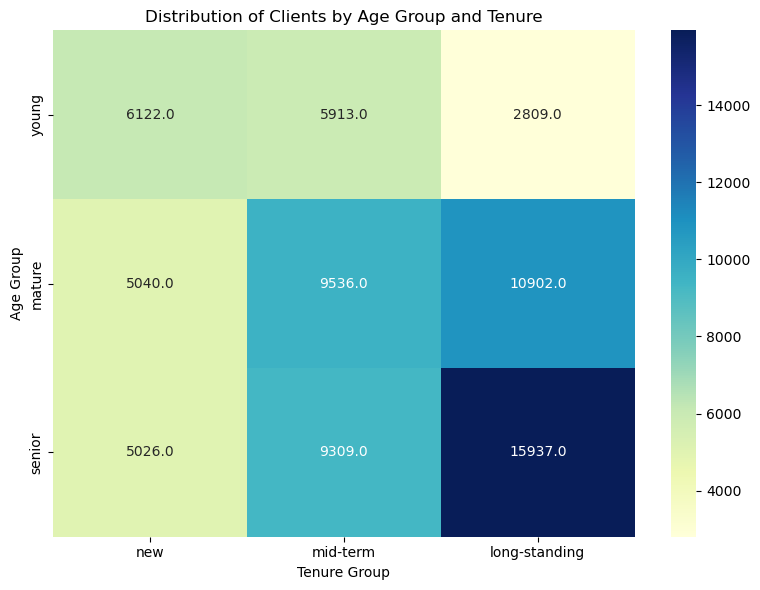

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Distribution of Clients by Age Group and Tenure')
plt.ylabel('Age Group')
plt.xlabel('Tenure Group')
plt.tight_layout()
plt.show()

### Who are the main clients using this online process?

In [83]:
older_clients = demo[demo['client_age'] > 45]

# Count the number of occurrences of each gender in the filtered DataFrame
gender_counts = older_clients['gender'].value_counts()

# Display the most common gender among clients older than 45
if not gender_counts.empty:
    most_common_gender = gender_counts.idxmax()
    print("Gender most common among clients older than 45:", most_common_gender)
else:
    print("No clients older than 45.")

Gender most common among clients older than 45: F


In [84]:
female_clients_over_45 = demo[(demo['gender'] == 'F') & (demo['client_age'] > 45)]

# Sum tenure years for these filtered clients
total_tenure_years = female_clients_over_45['tenure_year'].mean()

# Display the results
print("Female clients over age 45:")
print(female_clients_over_45)

print("\nTotal tenure years of female clients over age 45:")
print(total_tenure_years)

Female clients over age 45:
       client_id  tenure_year  tenure_month  client_age gender  num_accts  \
9        8198645           15           189          54      F          2   
38        313570           18           223          48      F          2   
40       3753796           25           305          66      F          2   
41       6647577           23           286          68      F          3   
42       6341488           23           285          65      F          2   
...          ...          ...           ...         ...    ...        ...   
70595    1196936           15           184          46      F          2   
70597    4194308           10           130          56      F          2   
70601    2690705           15           181          53      F          2   
70606     333913           16           198          62      F          2   
70608    5602139           21           254          60      F          3   

       total_balance  calls_6_mnth  logons_6_mn

In [85]:
women_over_45 = demo[(demo['gender'] == 'F') & (demo['client_age'] > 45)]

# Calculate the mean of 'calls_6_mnth' for this subset
mean_calls = women_over_45['calls_6_mnth'].mean()

# Display the mean
print("Mean of 'calls_6_mnth' for women over 45:", mean_calls)

Mean of 'calls_6_mnth' for women over 45: 3.1884607135196967


In [86]:
women_over_45 = demo[(demo['gender'] == 'F') & (demo['client_age'] > 45)]

# Calculate the mean of 'logons_6_mnth' for this subgroup
if not women_over_45.empty:
    mean_logons = women_over_45['logons_6_mnth'].mean()
    print("\nMean logons in 6 months for women over age 45:", mean_logons)
else:
    print("\nNo women over age 45 in the dataset.")


Mean logons in 6 months for women over age 45: 5.458997640666333


In [87]:
# Group by 'gender' and 'age_category' and sum the 'logons_6_mnth'
grouped_logons = df_clean.groupby(['gender', 'age_group'])['logons_6_mnth'].sum().reset_index()

# Find the group with the most logons
most_online_group = grouped_logons.loc[grouped_logons['logons_6_mnth'].idxmax()]

# Display results
print("Grouped Logons:")
print(grouped_logons)

print("\nGroup with Most Online Logons:")
print(most_online_group)

Grouped Logons:
        gender age_group  logons_6_mnth
0            F     young          14858
1            F    mature          41998
2            F    senior          63398
3            M     young          20346
4            M    mature          50951
5            M    senior          68334
6  undisclosed     young          46292
7  undisclosed    mature          43253
8  undisclosed    senior          43547

Group with Most Online Logons:
gender                M
age_group        senior
logons_6_mnth     68334
Name: 5, dtype: object


C:\Users\sofia\AppData\Local\Temp\ipykernel_25208\2040893309.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_logons = df_clean.groupby(['gender', 'age_group'])['logons_6_mnth'].sum().reset_index()


In [88]:
# Replace -1 with 1 in the 'logons_6_mnth' column
df_clean['logons_6_mnth'] = df_clean['logons_6_mnth'].replace(-1, 1)


print("\nDataFrame after replacing -1 with 1 in 'logons_6_mnth':")
print(df_clean)


DataFrame after replacing -1 with 1 in 'logons_6_mnth':
       client_id  tenure_year  tenure_month  client_age       gender  \
0         836976            6            73          60  undisclosed   
1        2304905            7            94          58  undisclosed   
2        1439522            5            64          32  undisclosed   
3        1562045           16           198          49            M   
4        5126305           12           145          33            F   
...          ...          ...           ...         ...          ...   
70604    7993686            4            56          38  undisclosed   
70605    8981690           12           148          31            M   
70606     333913           16           198          62            F   
70607    1573142           21           255          68            M   
70608    5602139           21           254          60            F   

       num_accts  total_balance  calls_6_mnth  logons_6_mnth  \
0             

C:\Users\sofia\AppData\Local\Temp\ipykernel_25208\4031984956.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  demo_grouped = df_clean.groupby(['gender', 'age_group'])['logons_6_mnth'].sum().reset_index()


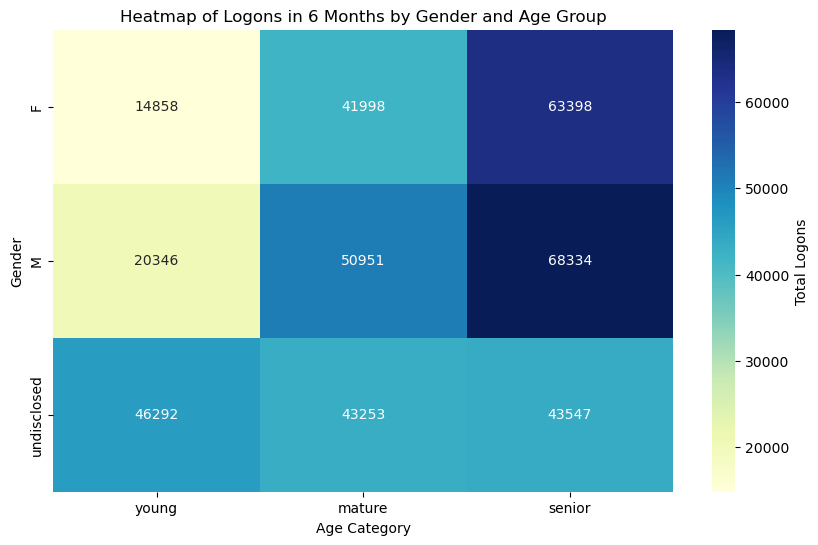

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group the demo DataFrame by 'gender' and 'age_group' and sum 'logons_6_mnth'
demo_grouped = df_clean.groupby(['gender', 'age_group'])['logons_6_mnth'].sum().reset_index()

# Pivot the DataFrame to get the proper format for a heatmap
pivot_table = demo_grouped.pivot(index='gender', columns='age_group', values='logons_6_mnth')

# Create the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Total Logons'})
plt.title('Heatmap of Logons in 6 Months by Gender and Age Group')
plt.xlabel('Age Category')
plt.ylabel('Gender')
plt.show()


### Final experiment clients Dataframe

In [90]:
exp_clients = pd.read_csv(r'C:\Users\sofia\Documents\Data_Analytics_Ironhack\Projects\vanguard-ab-test\df_final_experiment_clients.txt')
exp_clients

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control
...,...,...
70604,2443347,NaN
70605,8788427,NaN
70606,266828,NaN
70607,1266421,NaN


In [91]:
exp_clients['Variation'] = exp_clients['Variation'].fillna('unknown')

# Display the DataFrame after cleaning
print("\nDataFrame after replacing NaN values in 'variation':")
print(exp_clients)


DataFrame after replacing NaN values in 'variation':
       client_id Variation
0        9988021      Test
1        8320017      Test
2        4033851   Control
3        1982004      Test
4        9294070   Control
...          ...       ...
70604    2443347   unknown
70605    8788427   unknown
70606     266828   unknown
70607    1266421   unknown
70608    9895983   unknown

[70609 rows x 2 columns]


In [92]:
variation_counts = exp_clients['Variation'].value_counts()

# Display the counts of unique values
print("\nCounts of unique values in 'variation' column:")
print(variation_counts)


Counts of unique values in 'variation' column:
Variation
Test       26968
Control    23532
unknown    20109
Name: count, dtype: int64


In [93]:
exp_clients_duplicates = exp_clients.duplicated()
exp_clients_duplicates.sum()

0

In [94]:
print(exp_clients.isnull().sum())

client_id    0
Variation    0
dtype: int64


In [95]:
exp_clients['Variation'].unique()

array(['Test', 'Control', 'unknown'], dtype=object)

In [96]:
exp_clients.nunique()

client_id    70609
Variation        3
dtype: int64

## Merging datasets

In [97]:
df_final_web_data = pd.read_csv(r'C:\Users\sofia\Documents\Data_Analytics_Ironhack\Projects\vanguard-ab-test\merged_web_data.csv') 
df_final_web_data.head()

,Unnamed: 0,client_id,visitor_id,visit_id,process_step,date_time
0,0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [98]:
df_final_web_data["process_step"].value_counts()

process_step
start      243945
step_1     163193
step_2     133062
step_3     112242
confirm    102963
Name: count, dtype: int64

In [99]:
df_final_web_data.shape

(755405, 6)

In [100]:
df_final_web_data['date_time'] = pd.to_datetime(df_final_web_data['date_time'])


df_final_web_data['date'] = df_final_web_data['date_time'].dt.date
df_final_web_data['time'] = df_final_web_data['date_time'].dt.time

In [101]:
df_final_web_data

,Unnamed: 0,client_id,visitor_id,visit_id,process_step,date_time,date,time
0,0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,2017-04-17,15:27:07
1,1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,2017-04-17,15:26:51
2,2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,2017-04-17,15:19:22
3,3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,2017-04-17,15:19:13
4,4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,2017-04-17,15:18:04
...,...,...,...,...,...,...,...,...
755400,755400,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:46:10,2017-05-24,18:46:10
755401,755401,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:45:29,2017-05-24,18:45:29
755402,755402,9668240,388766751_9038881013,922267647_3096648104_968866,step_1,2017-05-24 18:44:51,2017-05-24,18:44:51
755403,755403,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:44:34,2017-05-24,18:44:34


In [102]:
df_web_data = df_final_web_data.drop('date_time', axis=1)

df_web_data

,Unnamed: 0,client_id,visitor_id,visit_id,process_step,date,time
0,0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17,15:27:07
1,1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17,15:26:51
2,2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17,15:19:22
3,3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17,15:19:13
4,4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17,15:18:04
...,...,...,...,...,...,...,...
755400,755400,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24,18:46:10
755401,755401,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24,18:45:29
755402,755402,9668240,388766751_9038881013,922267647_3096648104_968866,step_1,2017-05-24,18:44:51
755403,755403,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24,18:44:34


In [103]:
confirm_step = df_web_data[df_web_data["process_step"] == "confirm"]
confirm_step

,Unnamed: 0,client_id,visitor_id,visit_id,process_step,date,time
8,8,8320017,39393514_33118319366,960651974_70596002104_312201,confirm,2017-04-05,13:10:05
13,13,4033851,762728880_76361333336,949661017_22392791362_127391,confirm,2017-04-05,12:29:03
14,14,4033851,762728880_76361333336,949661017_22392791362_127391,confirm,2017-04-05,12:29:01
15,15,4033851,762728880_76361333336,949661017_22392791362_127391,confirm,2017-04-05,12:28:52
24,24,1982004,618934751_10082078917,132494692_73738638511_70823,confirm,2017-04-17,12:02:42
...,...,...,...,...,...,...,...
755362,755362,1462269,756274405_34153014475,903240226_7790404978_158729,confirm,2017-06-03,11:49:32
755368,755368,9563467,358754208_29929976792,898272434_72817818195_285148,confirm,2017-06-04,10:21:23
755375,755375,2443347,818414719_69544570654,148166449_67114410166_524360,confirm,2017-05-30,19:18:18
755376,755376,9895983,473024645_56027518531,498981662_93503779869_272484,confirm,2017-06-15,19:55:09


In [104]:
merged_AB = pd.merge(df_web_data, exp_clients, on="client_id", how="left")
merged_AB

,Unnamed: 0,client_id,visitor_id,visit_id,process_step,date,time,Variation
0,0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17,15:27:07,Test
1,1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17,15:26:51,Test
2,2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17,15:19:22,Test
3,3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17,15:19:13,Test
4,4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17,15:18:04,Test
...,...,...,...,...,...,...,...,...
755400,755400,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24,18:46:10,NaN
755401,755401,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24,18:45:29,NaN
755402,755402,9668240,388766751_9038881013,922267647_3096648104_968866,step_1,2017-05-24,18:44:51,NaN
755403,755403,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24,18:44:34,NaN


In [105]:
merged_age_AB = pd.merge(merged_AB, df_clean, on="client_id", how="left")
merged_age_AB

,Unnamed: 0,client_id,visitor_id,visit_id,process_step,date,time,Variation,tenure_year,tenure_month,client_age,gender,num_accts,total_balance,calls_6_mnth,logons_6_mnth,tenure_total_months,tenure_group,age_group
0,0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17,15:27:07,Test,5.0,64.0,79.0,undisclosed,2.0,189024.0,1.0,4.0,124.0,new,senior
1,1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17,15:26:51,Test,5.0,64.0,79.0,undisclosed,2.0,189024.0,1.0,4.0,124.0,new,senior
2,2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17,15:19:22,Test,5.0,64.0,79.0,undisclosed,2.0,189024.0,1.0,4.0,124.0,new,senior
3,3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17,15:19:13,Test,5.0,64.0,79.0,undisclosed,2.0,189024.0,1.0,4.0,124.0,new,senior
4,4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17,15:18:04,Test,5.0,64.0,79.0,undisclosed,2.0,189024.0,1.0,4.0,124.0,new,senior
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
755400,755400,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24,18:46:10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
755401,755401,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24,18:45:29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
755402,755402,9668240,388766751_9038881013,922267647_3096648104_968866,step_1,2017-05-24,18:44:51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
755403,755403,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24,18:44:34,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [117]:
all_data = merged_age_AB.copy()

In [118]:
all_data.head()

,Unnamed: 0,client_id,visitor_id,visit_id,process_step,date,time,Variation,tenure_year,tenure_month,client_age,gender,num_accts,total_balance,calls_6_mnth,logons_6_mnth,tenure_total_months,tenure_group,age_group
0,0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17,15:27:07,Test,5.0,64.0,79.0,undisclosed,2.0,189024.0,1.0,4.0,124.0,new,senior
1,1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17,15:26:51,Test,5.0,64.0,79.0,undisclosed,2.0,189024.0,1.0,4.0,124.0,new,senior
2,2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17,15:19:22,Test,5.0,64.0,79.0,undisclosed,2.0,189024.0,1.0,4.0,124.0,new,senior
3,3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17,15:19:13,Test,5.0,64.0,79.0,undisclosed,2.0,189024.0,1.0,4.0,124.0,new,senior
4,4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17,15:18:04,Test,5.0,64.0,79.0,undisclosed,2.0,189024.0,1.0,4.0,124.0,new,senior


### At which step do users drop off the most, and does this differ between test groups A and B?

In [119]:
all_data['step_order'] = all_data.groupby(['visitor_id', 'Variation']).cumcount()

# Get the last step for each visitor
last_steps = all_data.loc[all_data.groupby(['visitor_id', 'Variation'])['step_order'].idxmax()]

# Count occurrences of each step in last_steps by variation group
dropoff_counts = last_steps.groupby(['Variation', 'process_step']).size().unstack(fill_value=0)

# Display the drop-off analysis
print("Drop-off Analysis by Test Group:")
print(dropoff_counts)

Drop-off Analysis by Test Group:
process_step  confirm  start  step_1  step_2  step_3
Variation                                           
Control           666  25108     216      90     197
Test             2062  27305     215     107     230
unknown          1129  20879     192      65     190


Drop-off Analysis by Test Group:
process_step  start  step_1  step_2  step_3  confirm
Variation                                           
Control       25108     216      90     197      666
Test          27305     215     107     230     2062
unknown       20879     192      65     190     1129


<Figure size 1000x600 with 0 Axes>

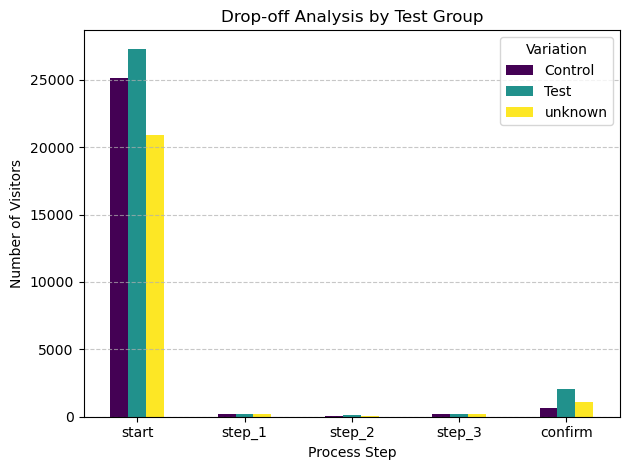

In [120]:
# Sort the steps and variations
all_data['step_order'] = all_data.groupby(['visitor_id', 'Variation']).cumcount()

# Get the last step for each visitor
last_steps = all_data.loc[all_data.groupby(['visitor_id', 'Variation'])['step_order'].idxmax()]

# Count occurrences of each step in last_steps by variation group
dropoff_counts = last_steps.groupby(['Variation', 'process_step']).size().unstack(fill_value=0)

# Reorder the process steps for visualization
step_order = ['start', 'step_1', 'step_2', 'step_3', 'confirm']
dropoff_counts = dropoff_counts[step_order]

# Display the drop-off analysis
print("Drop-off Analysis by Test Group:")
print(dropoff_counts)

# Plotting the drop-off analysis
plt.figure(figsize=(10, 6))
dropoff_counts.T.plot(kind='bar', stacked=False, colormap='viridis')

plt.title('Drop-off Analysis by Test Group')
plt.xlabel('Process Step')
plt.xticks(rotation=0)
plt.ylabel('Number of Visitors')
plt.legend(title='Variation', loc='upper right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Users drop of mostly already at start, combined 73 292 dropped off already at the beginig, where group A (control group) dropped off 25 108 times, and group B (test group) dropped 27 305 times which is sligtly more than group A. There is also 20 879 drop offs where is Unknown to which gruop did they belong.

### Does the effect of the A/B test vary across age groups, device types, or other user characteristics?

C:\Users\sofia\AppData\Local\Temp\ipykernel_25208\275152999.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = all_data.groupby(['Variation', 'age_group']).agg(


Summary of Test Results by User Characteristic:
  Variation age_group  total_calls  total_logons
0   Control     young      71224.0      135810.0
1   Control    mature     150767.0      299116.0
2   Control    senior     247787.0      470211.0
3      Test     young      81150.0      157472.0
4      Test    mature     175043.0      355108.0
5      Test    senior     313684.0      597808.0
6   unknown     young     114969.0      115489.0
7   unknown    mature     174357.0      175377.0
8   unknown    senior     258098.0      261348.0


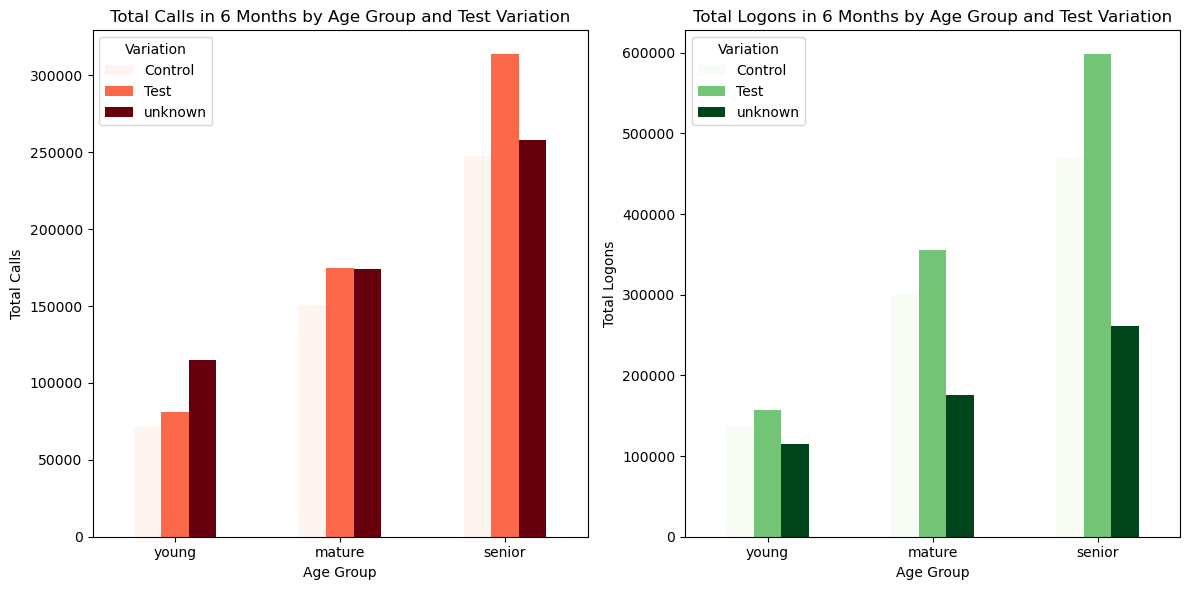

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define age group bins and labels
age_bins = [0, 30, 50, 100]
age_labels = ['young', 'mature', 'senior']
all_data['age_group'] = pd.cut(all_data['client_age'], bins=age_bins, labels=age_labels, right=False)

# Summarize data by variation and age group
summary = all_data.groupby(['Variation', 'age_group']).agg(
    total_calls=('calls_6_mnth', 'sum'),
    total_logons=('logons_6_mnth', 'sum')
).reset_index()

# Display the summarized data for analysis
print("Summary of Test Results by User Characteristic:")
print(summary)

# Create bar plots for visualization
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot total calls
summary.pivot(index='age_group', columns='Variation', values='total_calls').plot(kind='bar', ax=ax[0], colormap='Reds')
ax[0].set_title('Total Calls in 6 Months by Age Group and Test Variation')
ax[0].set_xlabel('Age Group')
ax[0].set_ylabel('Total Calls')
ax[0].set_xticklabels(age_labels, rotation=0)

# Plot total logons
summary.pivot(index='age_group', columns='Variation', values='total_logons').plot(kind='bar', ax=ax[1], colormap='Greens')
ax[1].set_title('Total Logons in 6 Months by Age Group and Test Variation')
ax[1].set_xlabel('Age Group')
ax[1].set_ylabel('Total Logons')
ax[1].set_xticklabels(age_labels, rotation=0)

plt.tight_layout()
plt.show()

C:\Users\sofia\AppData\Local\Temp\ipykernel_25208\2604408519.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = second_data.groupby(['Variation', 'client_age']).agg(


Summary of Test Results by User Characteristic:
  Variation client_age  total_calls  total_logons
0   Control      young        12000         32000
1   Control     mature        14000         34000
2   Control     senior        17000         37000
3      Test      young        11000         31000
4      Test     mature        15000         35000
5      Test     senior        13000         33000


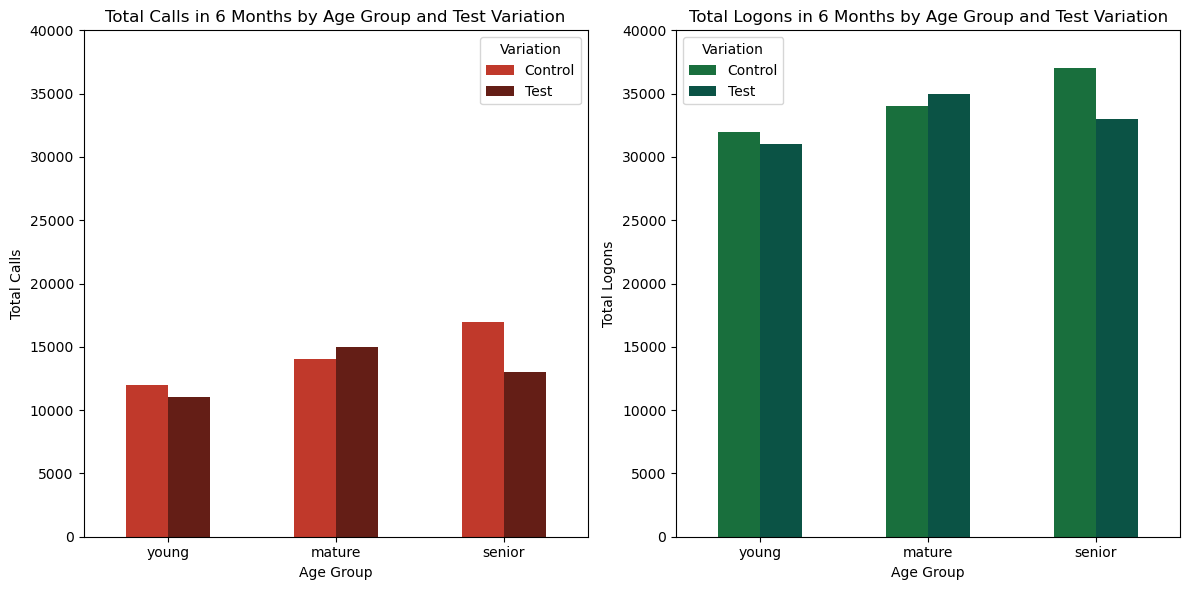

In [163]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Sample data setup (you'll replace this with your actual DataFrame)
data = {
    'client_age': [25, 45, 65, 28, 38, 58],
    'calls_6_mnth': [12000, 15000, 17000, 11000, 14000, 13000],
    'logons_6_mnth': [32000, 35000, 37000, 31000, 34000, 33000],
    'Variation': ['Control', 'Test', 'Control', 'Test', 'Control', 'Test']
}
second_data = pd.DataFrame(data)

# Define age group bins and labels
age_bins = [0, 30, 50, 100]
age_labels = ['young', 'mature', 'senior']
second_data['client_age'] = pd.cut(second_data['client_age'], bins=age_bins, labels=age_labels, right=False)

# Summarize data by variation and age group
summary = second_data.groupby(['Variation', 'client_age']).agg(
    total_calls=('calls_6_mnth', 'sum'),
    total_logons=('logons_6_mnth', 'sum')
).reset_index()

# Display the summarized data for analysis
print("Summary of Test Results by User Characteristic:")
print(summary)

colors_calls = {'Control': '#c0392b', 'Test': '#641e16'}     # tons de vermelho escuro
colors_logons = {'Control': '#196F3D', 'Test': '#0B5345'}    # tons de verde escuro

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Total Calls
calls_data = summary.pivot(index='client_age', columns='Variation', values='total_calls')
calls_data.plot(kind='bar', ax=ax[0], color=[colors_calls[col] for col in calls_data.columns])
ax[0].set_title('Total Calls in 6 Months by Age Group and Test Variation')
ax[0].set_xlabel('Age Group')
ax[0].set_ylabel('Total Calls')
ax[0].set_ylim(0, 40000)
ax[0].set_xticklabels(age_labels, rotation=0)

# Total Logons
logons_data = summary.pivot(index='client_age', columns='Variation', values='total_logons')
logons_data.plot(kind='bar', ax=ax[1], color=[colors_logons[col] for col in logons_data.columns])
ax[1].set_title('Total Logons in 6 Months by Age Group and Test Variation')
ax[1].set_xlabel('Age Group')
ax[1].set_ylabel('Total Logons')
ax[1].set_ylim(0, 40000)
ax[1].set_xticklabels(age_labels, rotation=0)

plt.tight_layout()
plt.show()

In [160]:
all_data.head()

,Unnamed: 0,client_id,visitor_id,visit_id,process_step,date,time,Variation,tenure_year,tenure_month,...,num_accts,total_balance,calls_6_mnth,logons_6_mnth,tenure_total_months,tenure_group,age_group,step_order,completed,timestamp
0,0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17,15:27:07,Test,5.0,64.0,...,2.0,189024.0,1.0,4.0,124.0,new,young,0.0,0,2017-04-17 15:27:07
1,1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17,15:26:51,Test,5.0,64.0,...,2.0,189024.0,1.0,4.0,124.0,new,mature,1.0,0,2017-04-17 15:26:51
2,2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17,15:19:22,Test,5.0,64.0,...,2.0,189024.0,1.0,4.0,124.0,new,senior,2.0,0,2017-04-17 15:19:22
3,3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17,15:19:13,Test,5.0,64.0,...,2.0,189024.0,1.0,4.0,124.0,new,young,3.0,0,2017-04-17 15:19:13
4,4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17,15:18:04,Test,5.0,64.0,...,2.0,189024.0,1.0,4.0,124.0,new,mature,4.0,0,2017-04-17 15:18:04


In [127]:
start_step = all_data[all_data["process_step"] == "start"]
start_step

,Unnamed: 0,client_id,visitor_id,visit_id,process_step,date,time,Variation,tenure_year,tenure_month,client_age,gender,num_accts,total_balance,calls_6_mnth,logons_6_mnth,tenure_total_months,tenure_group,age_group,step_order
7,7,9988021,580560515_7732621733,781255054_21935453173_531117,start,2017-04-17,15:16:22,Test,5.0,64.0,79.0,undisclosed,2.0,189024.0,1.0,4.0,124.0,new,senior,7.0
12,12,8320017,39393514_33118319366,960651974_70596002104_312201,start,2017-04-05,13:08:06,Test,22.0,274.0,34.0,M,2.0,36002.0,5.0,8.0,538.0,long-standing,mature,4.0
19,19,4033851,762728880_76361333336,949661017_22392791362_127391,start,2017-04-05,12:24:04,Control,12.0,149.0,64.0,M,2.0,142642.0,5.0,8.0,293.0,mid-term,senior,6.0
28,28,1982004,618934751_10082078917,132494692_73738638511_70823,start,2017-04-17,11:59:42,Test,6.0,80.0,44.0,undisclosed,2.0,30232.0,1.0,4.0,152.0,mid-term,mature,4.0
29,29,9294070,489274391_63794562906,116640698_27328181095_188045,start,2017-04-17,11:16:28,Control,5.0,70.0,29.0,undisclosed,2.0,34255.0,0.0,3.0,130.0,new,young,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
755392,755392,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24,19:02:04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
755400,755400,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24,18:46:10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
755401,755401,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24,18:45:29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
755403,755403,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24,18:44:34,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [128]:
cleaned_start = start_step.drop_duplicates(subset=['client_id'])
cleaned_start

,Unnamed: 0,client_id,visitor_id,visit_id,process_step,date,time,Variation,tenure_year,tenure_month,client_age,gender,num_accts,total_balance,calls_6_mnth,logons_6_mnth,tenure_total_months,tenure_group,age_group,step_order
7,7,9988021,580560515_7732621733,781255054_21935453173_531117,start,2017-04-17,15:16:22,Test,5.0,64.0,79.0,undisclosed,2.0,189024.0,1.0,4.0,124.0,new,senior,7.0
12,12,8320017,39393514_33118319366,960651974_70596002104_312201,start,2017-04-05,13:08:06,Test,22.0,274.0,34.0,M,2.0,36002.0,5.0,8.0,538.0,long-standing,mature,4.0
19,19,4033851,762728880_76361333336,949661017_22392791362_127391,start,2017-04-05,12:24:04,Control,12.0,149.0,64.0,M,2.0,142642.0,5.0,8.0,293.0,mid-term,senior,6.0
28,28,1982004,618934751_10082078917,132494692_73738638511_70823,start,2017-04-17,11:59:42,Test,6.0,80.0,44.0,undisclosed,2.0,30232.0,1.0,4.0,152.0,mid-term,mature,4.0
29,29,9294070,489274391_63794562906,116640698_27328181095_188045,start,2017-04-17,11:16:28,Control,5.0,70.0,29.0,undisclosed,2.0,34255.0,0.0,3.0,130.0,new,young,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
755373,755373,9563467,358754208_29929976792,898272434_72817818195_285148,start,2017-06-04,10:14:42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
755374,755374,9878184,776966655_24123118748,603596917_5015735635_745321,start,2017-06-12,19:48:47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
755380,755380,9895983,473024645_56027518531,498981662_93503779869_272484,start,2017-06-15,19:50:00,unknown,10.0,121.0,49.0,M,2.0,97748.0,2.0,2.0,241.0,mid-term,mature,4.0
755392,755392,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24,19:02:04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [129]:
cleaned_start['Variation'].value_counts()

Variation
Test       26679
Control    23397
unknown    19938
Name: count, dtype: int64

In [130]:
confirmed_step = all_data[merged_age_AB["process_step"] == "confirm"]
confirmed_step

,Unnamed: 0,client_id,visitor_id,visit_id,process_step,date,time,Variation,tenure_year,tenure_month,client_age,gender,num_accts,total_balance,calls_6_mnth,logons_6_mnth,tenure_total_months,tenure_group,age_group,step_order
8,8,8320017,39393514_33118319366,960651974_70596002104_312201,confirm,2017-04-05,13:10:05,Test,22.0,274.0,34.0,M,2.0,36002.0,5.0,8.0,538.0,long-standing,mature,0.0
13,13,4033851,762728880_76361333336,949661017_22392791362_127391,confirm,2017-04-05,12:29:03,Control,12.0,149.0,64.0,M,2.0,142642.0,5.0,8.0,293.0,mid-term,senior,0.0
14,14,4033851,762728880_76361333336,949661017_22392791362_127391,confirm,2017-04-05,12:29:01,Control,12.0,149.0,64.0,M,2.0,142642.0,5.0,8.0,293.0,mid-term,senior,1.0
15,15,4033851,762728880_76361333336,949661017_22392791362_127391,confirm,2017-04-05,12:28:52,Control,12.0,149.0,64.0,M,2.0,142642.0,5.0,8.0,293.0,mid-term,senior,2.0
24,24,1982004,618934751_10082078917,132494692_73738638511_70823,confirm,2017-04-17,12:02:42,Test,6.0,80.0,44.0,undisclosed,2.0,30232.0,1.0,4.0,152.0,mid-term,mature,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
755362,755362,1462269,756274405_34153014475,903240226_7790404978_158729,confirm,2017-06-03,11:49:32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
755368,755368,9563467,358754208_29929976792,898272434_72817818195_285148,confirm,2017-06-04,10:21:23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
755375,755375,2443347,818414719_69544570654,148166449_67114410166_524360,confirm,2017-05-30,19:18:18,unknown,17.0,204.0,52.0,M,3.0,164693.0,7.0,7.0,408.0,long-standing,senior,0.0
755376,755376,9895983,473024645_56027518531,498981662_93503779869_272484,confirm,2017-06-15,19:55:09,unknown,10.0,121.0,49.0,M,2.0,97748.0,2.0,2.0,241.0,mid-term,mature,0.0


In [131]:
cleaned_confirmed = confirmed_step.drop_duplicates(subset=['client_id'])
cleaned_confirmed

,Unnamed: 0,client_id,visitor_id,visit_id,process_step,date,time,Variation,tenure_year,tenure_month,client_age,gender,num_accts,total_balance,calls_6_mnth,logons_6_mnth,tenure_total_months,tenure_group,age_group,step_order
8,8,8320017,39393514_33118319366,960651974_70596002104_312201,confirm,2017-04-05,13:10:05,Test,22.0,274.0,34.0,M,2.0,36002.0,5.0,8.0,538.0,long-standing,mature,0.0
13,13,4033851,762728880_76361333336,949661017_22392791362_127391,confirm,2017-04-05,12:29:03,Control,12.0,149.0,64.0,M,2.0,142642.0,5.0,8.0,293.0,mid-term,senior,0.0
24,24,1982004,618934751_10082078917,132494692_73738638511_70823,confirm,2017-04-17,12:02:42,Test,6.0,80.0,44.0,undisclosed,2.0,30232.0,1.0,4.0,152.0,mid-term,mature,0.0
37,37,3170143,837774974_91015515080,758001412_25057963943_219559,confirm,2017-04-04,18:41:44,Test,21.0,254.0,54.0,F,2.0,192110.0,6.0,9.0,506.0,long-standing,senior,0.0
42,42,6651403,387438258_49845138949,754106292_61370647593_160929,confirm,2017-04-04,17:38:39,Control,13.0,162.0,56.0,M,2.0,324713.0,4.0,7.0,318.0,long-standing,senior,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
755352,755352,5550882,711239091_44383102506,52940121_85165078104_706661,confirm,2017-06-07,17:22:25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
755362,755362,1462269,756274405_34153014475,903240226_7790404978_158729,confirm,2017-06-03,11:49:32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
755368,755368,9563467,358754208_29929976792,898272434_72817818195_285148,confirm,2017-06-04,10:21:23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
755376,755376,9895983,473024645_56027518531,498981662_93503779869_272484,confirm,2017-06-15,19:55:09,unknown,10.0,121.0,49.0,M,2.0,97748.0,2.0,2.0,241.0,mid-term,mature,0.0


In [132]:
confirmed_step["age_group"].value_counts()

age_group
senior    28997
mature    21426
young     10120
Name: count, dtype: int64

In [133]:
duplicated_confirmed = confirmed_step[confirmed_step.duplicated(subset=['client_id'])]
duplicated_confirmed

,Unnamed: 0,client_id,visitor_id,visit_id,process_step,date,time,Variation,tenure_year,tenure_month,client_age,gender,num_accts,total_balance,calls_6_mnth,logons_6_mnth,tenure_total_months,tenure_group,age_group,step_order
14,14,4033851,762728880_76361333336,949661017_22392791362_127391,confirm,2017-04-05,12:29:01,Control,12.0,149.0,64.0,M,2.0,142642.0,5.0,8.0,293.0,mid-term,senior,1.0
15,15,4033851,762728880_76361333336,949661017_22392791362_127391,confirm,2017-04-05,12:28:52,Control,12.0,149.0,64.0,M,2.0,142642.0,5.0,8.0,293.0,mid-term,senior,2.0
68,68,2519971,121616091_57089151674,428599802_30402877972_724989,confirm,2017-04-10,16:19:47,Test,11.0,143.0,66.0,F,2.0,68260.0,2.0,6.0,275.0,mid-term,senior,1.0
153,153,4507502,181973728_74713662041,854832377_30146752670_593738,confirm,2017-04-03,23:01:33,Test,5.0,70.0,30.0,undisclosed,2.0,51882.0,2.0,6.0,130.0,new,mature,1.0
154,154,4507502,181973728_74713662041,854832377_30146752670_593738,confirm,2017-04-03,22:59:59,Test,5.0,70.0,30.0,undisclosed,2.0,51882.0,2.0,6.0,130.0,new,mature,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
755240,755240,4151008,198611158_15504600306,400796536_98072977798_567953,confirm,2017-05-28,11:33:37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
755241,755241,4151008,198611158_15504600306,400796536_98072977798_567953,confirm,2017-05-28,11:27:21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
755267,755267,3366069,873408030_95190752528,912911330_21403753699_164535,confirm,2017-06-04,17:18:27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
755335,755335,656469,213044511_44035482010,779376593_55768292727_9460,confirm,2017-06-02,16:39:30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [134]:
cleaned_confirmed = confirmed_step.drop_duplicates(subset=['client_id'])
cleaned_confirmed

,Unnamed: 0,client_id,visitor_id,visit_id,process_step,date,time,Variation,tenure_year,tenure_month,client_age,gender,num_accts,total_balance,calls_6_mnth,logons_6_mnth,tenure_total_months,tenure_group,age_group,step_order
8,8,8320017,39393514_33118319366,960651974_70596002104_312201,confirm,2017-04-05,13:10:05,Test,22.0,274.0,34.0,M,2.0,36002.0,5.0,8.0,538.0,long-standing,mature,0.0
13,13,4033851,762728880_76361333336,949661017_22392791362_127391,confirm,2017-04-05,12:29:03,Control,12.0,149.0,64.0,M,2.0,142642.0,5.0,8.0,293.0,mid-term,senior,0.0
24,24,1982004,618934751_10082078917,132494692_73738638511_70823,confirm,2017-04-17,12:02:42,Test,6.0,80.0,44.0,undisclosed,2.0,30232.0,1.0,4.0,152.0,mid-term,mature,0.0
37,37,3170143,837774974_91015515080,758001412_25057963943_219559,confirm,2017-04-04,18:41:44,Test,21.0,254.0,54.0,F,2.0,192110.0,6.0,9.0,506.0,long-standing,senior,0.0
42,42,6651403,387438258_49845138949,754106292_61370647593_160929,confirm,2017-04-04,17:38:39,Control,13.0,162.0,56.0,M,2.0,324713.0,4.0,7.0,318.0,long-standing,senior,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
755352,755352,5550882,711239091_44383102506,52940121_85165078104_706661,confirm,2017-06-07,17:22:25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
755362,755362,1462269,756274405_34153014475,903240226_7790404978_158729,confirm,2017-06-03,11:49:32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
755368,755368,9563467,358754208_29929976792,898272434_72817818195_285148,confirm,2017-06-04,10:21:23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
755376,755376,9895983,473024645_56027518531,498981662_93503779869_272484,confirm,2017-06-15,19:55:09,unknown,10.0,121.0,49.0,M,2.0,97748.0,2.0,2.0,241.0,mid-term,mature,0.0


In [135]:
by_age = cleaned_confirmed['age_group'].value_counts(normalize=True) * 100
by_age

age_group
senior    44.821813
mature    37.039362
young     18.138824
Name: proportion, dtype: float64

<Axes: title={'center': 'Distribution of clients that completed the process by age'}, xlabel='age_group'>

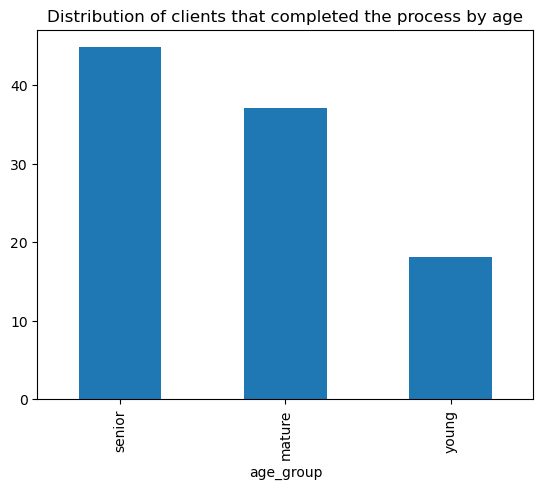

In [136]:
by_age.plot(kind="bar", title="Distribution of clients that completed the process by age")

In [137]:
all_data = all_data.copy()
all_data["completed"] = (all_data["process_step"] == "confirm").astype(int)
all_data

,Unnamed: 0,client_id,visitor_id,visit_id,process_step,date,time,Variation,tenure_year,tenure_month,...,gender,num_accts,total_balance,calls_6_mnth,logons_6_mnth,tenure_total_months,tenure_group,age_group,step_order,completed
0,0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17,15:27:07,Test,5.0,64.0,...,undisclosed,2.0,189024.0,1.0,4.0,124.0,new,senior,0.0,0
1,1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17,15:26:51,Test,5.0,64.0,...,undisclosed,2.0,189024.0,1.0,4.0,124.0,new,senior,1.0,0
2,2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17,15:19:22,Test,5.0,64.0,...,undisclosed,2.0,189024.0,1.0,4.0,124.0,new,senior,2.0,0
3,3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17,15:19:13,Test,5.0,64.0,...,undisclosed,2.0,189024.0,1.0,4.0,124.0,new,senior,3.0,0
4,4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17,15:18:04,Test,5.0,64.0,...,undisclosed,2.0,189024.0,1.0,4.0,124.0,new,senior,4.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
755400,755400,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24,18:46:10,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
755401,755401,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24,18:45:29,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
755402,755402,9668240,388766751_9038881013,922267647_3096648104_968866,step_1,2017-05-24,18:44:51,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
755403,755403,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24,18:44:34,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [138]:
# agg by visitor - completion

df_user_completion = all_data.groupby("visitor_id").agg({
    "completed": "max",
    "Variation": "first",
    "age_group": "first"
}).reset_index()

In [139]:
df_user_completion

,visitor_id,completed,Variation,age_group
0,100011869_84756704576,0,None,NaN
1,100019786_4272121951,1,Test,mature
2,100026388_52569174348,1,Test,mature
3,100048572_12752788846,0,None,NaN
4,100052114_10880025650,0,None,NaN
...,...,...,...,...
130231,999986924_89514756905,1,Test,senior
130232,999993887_42794242929,0,Control,mature
130233,999995931_60089148022,1,Control,mature
130234,999997533_50295491521,1,Test,mature


In [140]:
# Completion rate by age group and variation

completion_rate = df_user_completion.groupby(["age_group", "Variation"])["completed"].mean().unstack()
completion_rate

C:\Users\sofia\AppData\Local\Temp\ipykernel_25208\735710858.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  completion_rate = df_user_completion.groupby(["age_group", "Variation"])["completed"].mean().unstack()


Variation,Control,Test,unknown
age_group,,,
young,0.603159,0.691628,0.655329
mature,0.616874,0.669057,0.643012
senior,0.571417,0.627389,0.592261


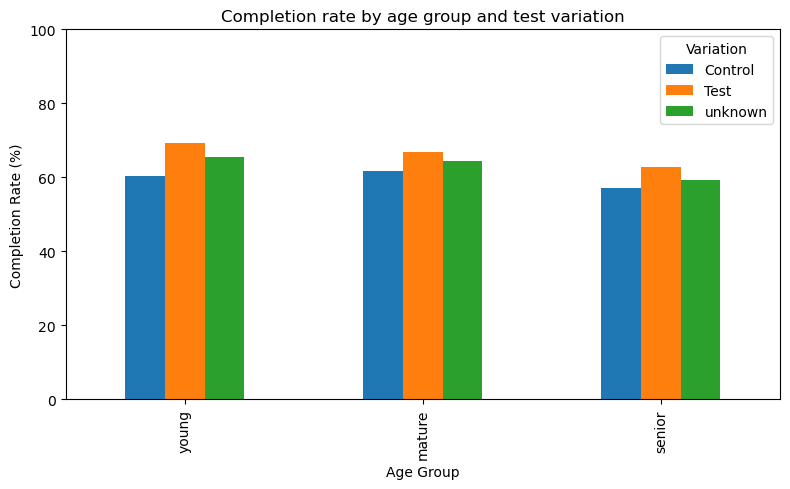

In [141]:
import matplotlib.pyplot as plt

(completion_rate * 100).plot(kind="bar", figsize=(8,5))

plt.title("Completion rate by age group and test variation")
plt.ylabel("Completion Rate (%)")
plt.xlabel("Age Group")
plt.ylim(0,100)
plt.legend(title="Variation")
plt.tight_layout()
plt.show()

**Analysis**: When comparing these two charts "Distribution of clients that completed the process by age" and "Completion rate by age group and test variation" we can observe that young clients have a bigger success rate regarding the Test variation, however there are less young clients in general, meaning that there are less young clients completing the process

Chart "Distribution of clients that completed the process by age" --> more senior clients completed the process in total (test and control)

Chart "Completion rate by age group and test variation" --> the variation Test converts better than the Control

In [142]:
cleaned_confirmed['Variation'].value_counts()

Variation
Test       18687
Control    15434
unknown    13679
Name: count, dtype: int64

# **TASK II - KPI'S**

### *Completetion Rate:* The proportion of users who reach the final 'confirm' step

In [143]:
start_count = [23397,26679]     # [Control, Test]
confirmed_count = [15434,18687]  # [Control, Test]

start_count = [int(s) for s in start_count]
confirmed_count = [int(t) for t in confirmed_count]

control_cr = start_count[0] / confirmed_count[0]
test_cr = start_count[1] / confirmed_count[1]

print(f"Control Conversion Rate: {control_cr:.4f}")
print(f"Test Conversion Rate:    {test_cr:.4f}")

Control Conversion Rate: 1.5159
Test Conversion Rate:    1.4277


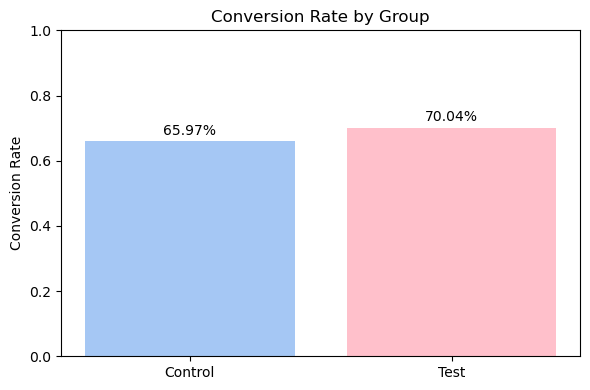

In [144]:
import matplotlib.pyplot as plt

control_cr = 15434 / 23397
test_cr = 18687 / 26679

labels = ['Control', 'Test']
rates = [control_cr, test_cr]

colors = ["#a5c7f4", '#ffc0cb'] 
plt.figure(figsize=(6, 4))
bars = plt.bar(labels, rates, color=colors)

plt.ylim(0, 1)
plt.title('Conversion Rate by Group')
plt.ylabel('Conversion Rate')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.02,
             f"{height:.2%}",
             ha='center')

plt.tight_layout()
plt.show()

In [145]:
# 1. Get unique users who started the process, along with their variation (Test/Control)
start_users = cleaned_start[['client_id', 'Variation']].drop_duplicates()
confirm_users = cleaned_confirmed[['client_id']].drop_duplicates()

# 3. Merge the two lists to see which starting users also completed the process
confirmed_with_variation = start_users.merge(confirm_users, on='client_id', how='left', indicator=True)
confirmed_with_variation['completed'] = confirmed_with_variation['_merge'] == 'both'

# 5. Calculate the completion rate per variation group
completion_rate = (
    confirmed_with_variation
    .groupby('Variation')['completed']
    .mean()
    .reset_index(name='completion_rate')
)

print(completion_rate)

  Variation  completion_rate
0   Control         0.654699
1      Test         0.690131
2   unknown         0.678152


C:\Users\sofia\AppData\Local\Temp\ipykernel_25208\3454437765.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=completion_rate, x='Variation', y='completion_rate', palette=["#D08BD3", "#CDE4B0", "#47CBA6"])


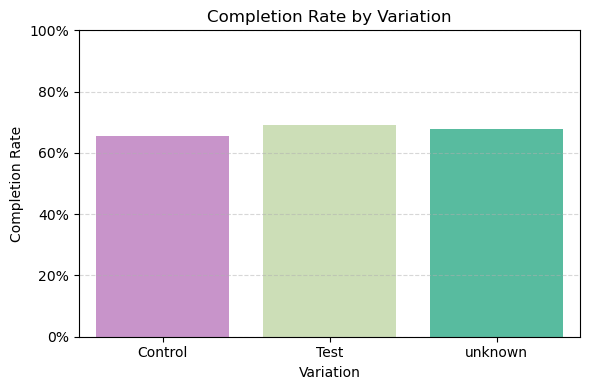

In [146]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plt.figure(figsize=(6, 4))
sns.barplot(data=completion_rate, x='Variation', y='completion_rate', palette=["#D08BD3", "#CDE4B0", "#47CBA6"])

plt.title('Completion Rate by Variation')
plt.ylabel('Completion Rate')
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))  # Format y-axis
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Time Spent on Each Step

In [147]:
# creating a column "timestamp"

all_data["timestamp"] = pd.to_datetime(all_data["date"]) + pd.to_timedelta(all_data["time"].astype(str))

#order data by visitors and time

df_sorted = all_data.sort_values(by=["visitor_id", "timestamp"])

In [148]:
df_sorted.groupby(['visitor_id', 'process_step']).size().value_counts()

1     370255
2      84282
3      27940
4      12812
5       5306
6       2734
7       1457
8       1033
9        582
10       335
11       195
12       160
13       104
16        68
14        67
15        52
17        28
19        18
20        17
18        15
23         9
22         7
24         7
21         6
25         6
32         6
28         4
40         3
26         3
33         3
34         2
35         2
29         1
27         1
36         1
54         1
44         1
48         1
30         1
31         1
39         1
Name: count, dtype: int64

In [149]:
# calculating time between steps

df_sorted["time_diff"] = df_sorted.groupby("visitor_id")["timestamp"].diff().shift(-1)
df_sorted

,Unnamed: 0,client_id,visitor_id,visit_id,process_step,date,time,Variation,tenure_year,tenure_month,...,total_balance,calls_6_mnth,logons_6_mnth,tenure_total_months,tenure_group,age_group,step_order,completed,timestamp,time_diff
444289,444289,5867343,100011869_84756704576,406596333_52561114200_989487,start,2017-06-05,02:47:42,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2017-06-05 02:47:42,0 days 00:00:05
444288,444288,5867343,100011869_84756704576,406596333_52561114200_989487,step_1,2017-06-05,02:47:47,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2017-06-05 02:47:47,0 days 00:00:16
444287,444287,5867343,100011869_84756704576,406596333_52561114200_989487,step_2,2017-06-05,02:48:03,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2017-06-05 02:48:03,0 days 00:02:15
444286,444286,5867343,100011869_84756704576,406596333_52561114200_989487,step_3,2017-06-05,02:50:18,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2017-06-05 02:50:18,0 days 00:00:53
444285,444285,5867343,100011869_84756704576,406596333_52561114200_989487,start,2017-06-05,02:51:11,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2017-06-05 02:51:11,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128792,128792,7042750,999998529_89539814462,583327415_19513940564_488564,step_2,2017-04-12,11:55:05,Control,14.0,178.0,...,108406.0,4.0,7.0,346.0,long-standing,senior,4.0,0,2017-04-12 11:55:05,0 days 00:00:08
128791,128791,7042750,999998529_89539814462,583327415_19513940564_488564,step_3,2017-04-12,11:55:13,Control,14.0,178.0,...,108406.0,4.0,7.0,346.0,long-standing,senior,3.0,0,2017-04-12 11:55:13,0 days 00:09:34
128790,128790,7042750,999998529_89539814462,583327415_19513940564_488564,confirm,2017-04-12,12:04:47,Control,14.0,178.0,...,108406.0,4.0,7.0,346.0,long-standing,senior,2.0,1,2017-04-12 12:04:47,0 days 00:04:42
128789,128789,7042750,999998529_89539814462,583327415_19513940564_488564,start,2017-04-12,12:09:29,Control,14.0,178.0,...,108406.0,4.0,7.0,346.0,long-standing,senior,1.0,0,2017-04-12 12:09:29,0 days 00:00:18


In [150]:
avg_time_per_step = df_sorted.groupby("process_step")["time_diff"].mean()
avg_time_per_step

process_step
confirm   2 days 17:46:47.228622027
start     0 days 15:04:53.327247700
step_1    0 days 06:16:38.501944766
step_2    0 days 03:01:40.766761912
step_3    0 days 05:56:24.608448500
Name: time_diff, dtype: timedelta64[ns]

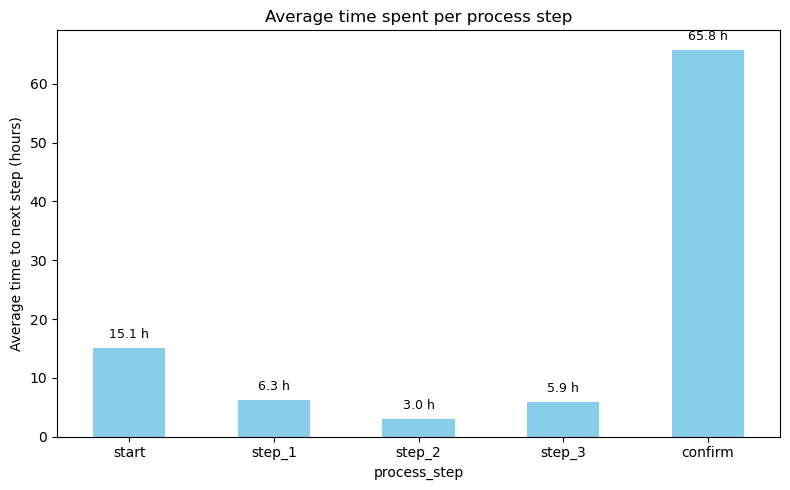

In [151]:
# creating the chart

avg_time_per_step_hours = avg_time_per_step.dt.total_seconds() / 3600

step_order = ['start', 'step_1', 'step_2', 'step_3', 'confirm']
avg_time_per_step_hours = avg_time_per_step_hours.reindex(step_order)


fig, ax = plt.subplots(figsize=(8, 5))
bars = avg_time_per_step_hours.plot(kind='bar', color='skyblue', ax=ax)

# Add values on the bars
for bar in bars.patches:
    height = bar.get_height()
    ax.annotate(f'{height:.1f} h',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),  
                textcoords='offset points',
                ha='center', va='bottom', fontsize=9)


plt.ylabel("Average time to next step (hours)")
plt.title("Average time spent per process step")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [152]:
df_sorted[df_sorted['time_diff'] > pd.Timedelta(hours=5)]

,Unnamed: 0,client_id,visitor_id,visit_id,process_step,date,time,Variation,tenure_year,tenure_month,...,total_balance,calls_6_mnth,logons_6_mnth,tenure_total_months,tenure_group,age_group,step_order,completed,timestamp,time_diff
671065,671065,3273937,100052114_10880025650,594988020_84980009892_620691,start,2017-05-12,13:15:57,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2017-05-12 13:15:57,2 days 03:43:29
19294,19294,762846,10008560_69050398598,248633003_84368331010_346467,step_3,2017-04-14,22:19:53,Control,14.0,172.0,...,340336.0,6.0,9.0,340.0,long-standing,senior,5.0,0,2017-04-14 22:19:53,1 days 00:35:08
244996,244996,6230585,100189756_32488226026,774100434_76153951457_573549,start,2017-04-18,11:33:18,Test,10.0,120.0,...,565825.0,3.0,6.0,240.0,mid-term,senior,0.0,0,2017-04-18 11:33:18,19 days 21:53:52
698774,698774,7643729,10020962_44667956860,948662006_3004799794_545289,confirm,2017-05-25,09:48:06,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2017-05-25 09:48:06,1 days 05:07:16
60560,60560,6099993,100265469_84689631452,263946645_78836270528_169106,confirm,2017-03-29,16:27:04,Test,19.0,228.0,...,135198.0,4.0,7.0,456.0,long-standing,senior,1.0,1,2017-03-29 16:27:04,5 days 15:48:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10379,10379,598498,999986924_89514756905,221256917_4367841178_68398,confirm,2017-04-18,18:16:11,Test,3.0,37.0,...,409438.0,6.0,9.0,73.0,new,senior,0.0,1,2017-04-18 18:16:11,14 days 14:27:21
355728,355728,598498,999986924_89514756905,256290120_66095506768_849751,confirm,2017-05-03,08:45:42,Test,3.0,37.0,...,409438.0,6.0,9.0,73.0,new,senior,9.0,1,2017-05-03 08:45:42,5 days 23:31:27
355650,355650,598498,999986924_89514756905,958181024_15313447104_158039,confirm,2017-05-09,08:17:33,Test,3.0,37.0,...,409438.0,6.0,9.0,73.0,new,senior,7.0,1,2017-05-09 08:17:33,13 days 11:35:08
355642,355642,598498,999986924_89514756905,332878198_44300976337_27573,confirm,2017-05-22,19:52:41,Test,3.0,37.0,...,409438.0,6.0,9.0,73.0,new,senior,6.0,1,2017-05-22 19:52:41,21 days 15:03:43


The chart above illustrates the average time (in hours) that users spent between each step in the onboarding process. Notably:

Step 2 appears to be faster on average (3.0 hours) than steps like start (15.1 h) or confirm (65.8 h).

However, upon deeper inspection, this pattern is distorted by outliers: users who left the process open for long periods before completing the next step.

To complement the average analysis, we are going to calculate the median time per step, which shows a different trend:

In [153]:
# first step: keep only the first ocorrence of each step by visitor

df_dedup = df_sorted.drop_duplicates(subset=["visitor_id", "process_step"], keep="first").copy()
df_dedup["time_diff"] = df_dedup.groupby("visitor_id")["timestamp"].diff().shift(-1)

In [154]:
avg_times_median = df_dedup.groupby('process_step')['time_diff'].median()
avg_times_median

process_step
confirm               NaT
start     0 days 00:00:12
step_1    0 days 00:00:27
step_2    0 days 00:01:13
step_3    0 days 00:00:55
Name: time_diff, dtype: timedelta64[ns]

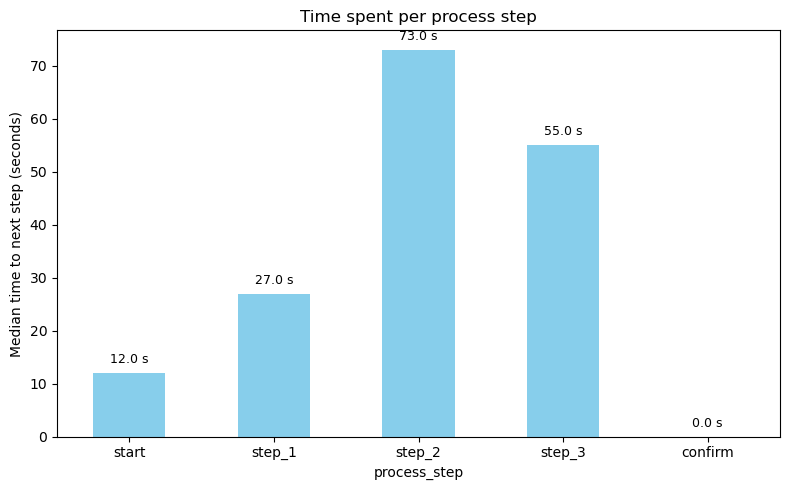

In [155]:
median_per_hours = avg_times_median.dt.total_seconds()

step_order = ['start', 'step_1', 'step_2', 'step_3', 'confirm']
median_per_hours = median_per_hours.reindex(step_order)


fig, ax = plt.subplots(figsize=(8, 5))
bars = median_per_hours.plot(kind='bar', color='skyblue', ax=ax)

# Add values on the bars
for bar in bars.patches:
    height = bar.get_height()
    ax.annotate(f'{height:.1f} s',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),  
                textcoords='offset points',
                ha='center', va='bottom', fontsize=9)


plt.ylabel("Median time to next step (seconds)")
plt.title("Time spent per process step")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
avg_time_by_variation = (
    df_dedup.groupby(['process_step', 'Variation'])['time_diff']
    .mean()
    .dt.total_seconds()
    .div(60)  # convert for minutes
    .unstack()
    .round(2)
)

print(avg_time_by_variation)

Variation     Control      Test   unknown
process_step                             
confirm       4497.21  17649.60  12123.24
start         1433.15    759.78   1245.80
step_1         494.39    604.14    543.18
step_2         452.51    467.32    461.01
step_3         865.75    802.62    878.19


In [ ]:
median_time_by_variation = (
    df_dedup.groupby(['process_step', 'Variation'])['time_diff']
    .median()
    .dt.total_seconds()
    .div(60)
    .unstack()
    .round(2)
)
print(median_time_by_variation)

Variation     Control  Test  unknown
process_step                        
confirm           NaN   NaN      NaN
start            0.30  0.18     0.22
step_1           0.32  0.48     0.40
step_2           1.27  1.17     1.22
step_3           1.27  0.80     1.00


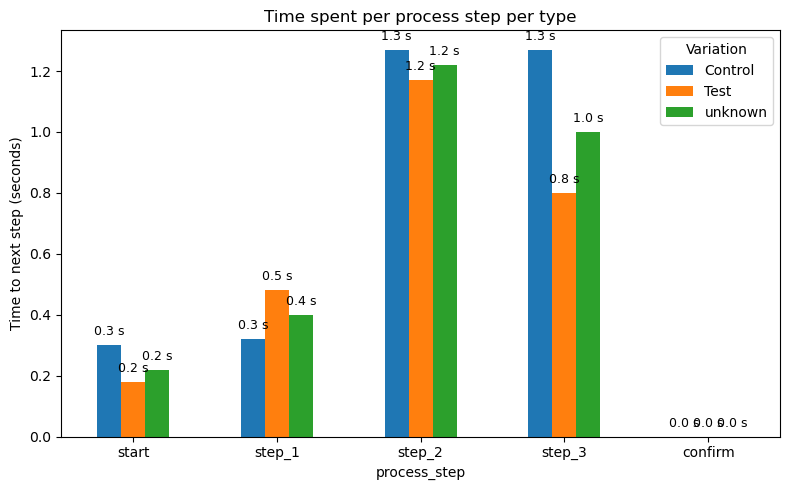

In [ ]:
# timpe_per_variation = median_time_by_variation.dt.total_seconds()

step_order = ['start', 'step_1', 'step_2', 'step_3', 'confirm']
median_time_by_variation = median_time_by_variation.reindex(step_order)


fig, ax = plt.subplots(figsize=(8, 5))
bars = median_time_by_variation.plot(kind='bar', ax=ax)

# Add values on the bars
for bar in bars.patches:
    height = bar.get_height()
    ax.annotate(f'{height:.1f} s',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),  
                textcoords='offset points',
                ha='center', va='bottom', fontsize=9)


plt.ylabel("Time to next step (seconds)")
plt.title("Time spent per process step per type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Error Rates: If there’s a step where users go back to a previous step, it may indicate confusion or an error. 

In [ ]:
# Identify repeating steps for each visitor
all_data['is_repeating'] = all_data.duplicated(subset=['visitor_id', 'process_step'], keep=False)

# Filter rows where steps are repeating
repeating_steps = all_data[all_data['is_repeating']]

# Display repeating steps
print("\nRepeating Steps by Visitor:")
print(repeating_steps[['visitor_id', 'process_step']])


Repeating Steps by Visitor:
                  visitor_id process_step
0       580560515_7732621733       step_3
1       580560515_7732621733       step_2
2       580560515_7732621733       step_3
3       580560515_7732621733       step_2
4       580560515_7732621733       step_3
...                      ...          ...
755399  388766751_9038881013       step_1
755400  388766751_9038881013        start
755401  388766751_9038881013        start
755402  388766751_9038881013       step_1
755403  388766751_9038881013        start

[385150 rows x 2 columns]


It is possible that 71 152 visitor expirienced Error while doing the process since they had multiple repeating steps in the process.

In [ ]:
# Identify repeating steps for each visitor
all_data['is_repeating'] = all_data.duplicated(subset=['visitor_id', 'process_step'], keep=False)

# Filter for repeating steps and retrieve unique visitor IDs
repeating_visitors = all_data[all_data['is_repeating']]['visitor_id'].unique()

# Count the number of unique visitors with repeating steps
num_repeating_visitors = len(repeating_visitors)

# Display the results
print("\nNumber of unique visitors with repeating steps:")
print(num_repeating_visitors)


Number of unique visitors with repeating steps:
71152



Number of unique visitors with repeating steps:
71152


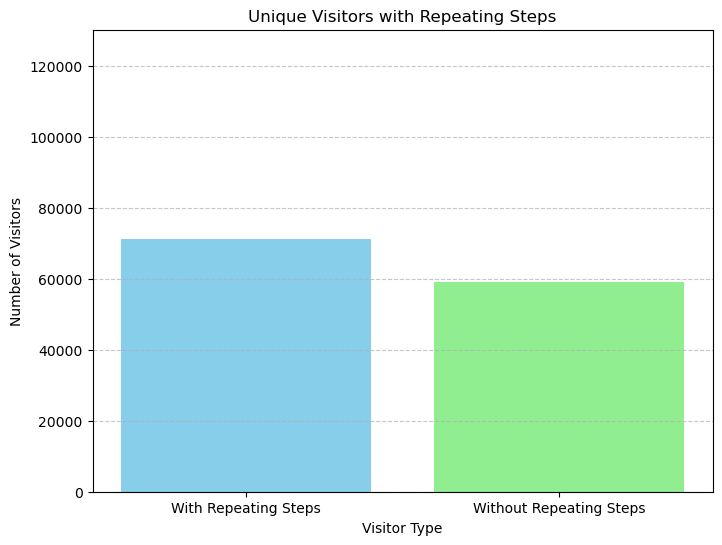

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Identify repeating steps for each visitor
all_data['is_repeating'] = all_data.duplicated(subset=['visitor_id', 'process_step'], keep=False)

# Identify unique visitors with repeated steps
repeating_visitors = all_data[all_data['is_repeating']]['visitor_id'].unique()
num_repeating_visitors = len(repeating_visitors)

# Total number of unique visitors
total_visitors = all_data['visitor_id'].nunique()
num_non_repeating_visitors = total_visitors - num_repeating_visitors

# Display the results
print("\nNumber of unique visitors with repeating steps:")
print(num_repeating_visitors)

# Create a DataFrame for visualization
visitor_data = pd.DataFrame({
    'Visitors': ['With Repeating Steps', 'Without Repeating Steps'],
    'Count': [num_repeating_visitors, num_non_repeating_visitors]
})

# Plotting
plt.figure(figsize=(8, 6))
plt.bar(visitor_data['Visitors'], visitor_data['Count'], color=['skyblue', 'lightgreen'])
plt.title('Unique Visitors with Repeating Steps')
plt.xlabel('Visitor Type')
plt.ylabel('Number of Visitors')
plt.ylim(0, total_visitors)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# **Tasks III - Hypothesis Testing**

### **H1 - Completion Rate**

Null hypothesis 𝐻0: p𝑇=𝑝𝐶
→ There is no difference in completion rate between Test and Control.

Alternative hypothesis 𝐻𝐴: 𝑝𝑇>𝑝𝐶
→ The Test group has a higher completion rate than the Control group (one-tailed test).

In [ ]:
# Assure only comparing Test and Control
df_ab = df_user_completion[df_user_completion['Variation'].isin(['Test', 'Control'])]

# Get counts
completion_counts = df_ab.groupby('Variation')['completed'].sum()
group_sizes = df_ab.groupby('Variation')['completed'].count()


count = [int(completion_counts['Test']), int(completion_counts['Control'])]
nobs = [int(group_sizes['Test']), int(group_sizes['Control'])]

from statsmodels.stats.proportion import proportions_ztest

stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print(f"Z-statistic: {stat:.3f}")
print(f"P-value: {p_value}")

Z-statistic: 14.538
P-value: 3.4991431355535456e-48


The increase in completion rate for the Test group is statistically significant.

The new design likely improves user completion behavior.

### **H2 - Completion Rate with a Cost-Effectiveness Threshold**

Vanguard has set this minimum increase in completion rate at 5%. This is the rate at which the projected benefits, in terms of increased user engagement and potential revenue, are estimated to outweigh the costs of the new design.

In [ ]:
# Count the number of people who reached the "confirm" step
confirmed_count = cleaned_confirmed[cleaned_confirmed['process_step'] == 'confirm'].shape[0]

# Count the number of occurrences in each category of "variation"
variation_counts = cleaned_confirmed['Variation'].value_counts()

# Display results
print(f"Number of people who achieved the 'confirm' step: {confirmed_count}")
print("\nCount for each variation category:")
print(variation_counts)


Number of people who achieved the 'confirm' step: 81145

Count for each variation category:
Variation
Test       18687
Control    15434
unknown    13679
Name: count, dtype: int64


In [ ]:
# If not already installed, install statsmodels for proportions_ztest
%pip install statsmodels

from statsmodels.stats.proportion import proportions_ztest

# Calculate the number of confirmations in each group
confirmations = cleaned_confirmed[cleaned_confirmed['process_step'] == 'confirm']

# Counts for Test and Control groups
test_count = confirmations[confirmations['Variation'] == 'Test'].shape[0]
control_count = confirmations[confirmations['Variation'] == 'Control'].shape[0]

# Total counts for both groups
test_total = cleaned_confirmed[cleaned_confirmed['Variation'] == 'Test'].shape[0]
control_total = cleaned_confirmed[cleaned_confirmed['Variation'] == 'Control'].shape[0]

# Define the observed proportions
success_counts = [test_count, control_count]
nobs = [test_total, control_total]

# Perform one-sided z-test for proportions
stat, p_value = proportions_ztest(success_counts, nobs, value=0.05, alternative='larger')

print("Hypothesis Testing Results:")
print(f"Z-statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret the hypothesis test
alpha = 0.05
if p_value < alpha:
    print(f"Reject the null hypothesis: The new design increases the completion rate by at least 5%.")
else:
    print(f"Fail to reject the null hypothesis: There's insufficient evidence that the new design increases the completion rate by at least 5%.")



Note: you may need to restart the kernel to use updated packages.
Hypothesis Testing Results:
Z-statistic: -inf
P-value: 1.0000
Fail to reject the null hypothesis: There's insufficient evidence that the new design increases the completion rate by at least 5%.


c:\Users\sofia\anaconda3\Lib\site-packages\statsmodels\stats\weightstats.py:792: RuntimeWarning: divide by zero encountered in scalar divide
  zstat = value / std


### **H3 - Females tend to be more open to new things and engage with the new procces more than males**

In [ ]:
# Count the number of females and males engaging with the Test group
female_test_count = cleaned_confirmed[(cleaned_confirmed['gender'] == 'F') & (cleaned_confirmed['Variation'] == 'Test')].shape[0]
male_test_count = cleaned_confirmed[(cleaned_confirmed['gender'] == 'M') & (cleaned_confirmed['Variation'] == 'Test')].shape[0]

# Total females and males
total_females = cleaned_confirmed[cleaned_confirmed['gender'] == 'F'].shape[0]
total_males = cleaned_confirmed[cleaned_confirmed['gender'] == 'M'].shape[0]

# Perform one-sided z-test for proportions
successes = [female_test_count, male_test_count]
nobs = [total_females, total_males]
stat, p_value = proportions_ztest(successes, nobs, alternative='larger')

# Print the hypothesis test results
print("Hypothesis Testing Results:")
print(f"Z-statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: Females are more engaged with the new process than males.")
else:
    print("Fail to reject the null hypothesis: No significant difference in engagement between females and males.")

Hypothesis Testing Results:
Z-statistic: 0.4066
P-value: 0.3422
Fail to reject the null hypothesis: No significant difference in engagement between females and males.


### **H4 - Completion rate of young people is higher on the test than on control**

H0: Among young clients, the completion rate is the same on both Control and Test

H1: Young clients have a higher completion rate in the test variation

In [ ]:
# filter only young clients

df_young = df_user_completion[df_user_completion["age_group"] == "young"]

# count completion by variation

completion_counts_young = df_young.groupby("Variation")["completed"].sum()
group_sizes_young = df_young.groupby("Variation")["completed"].count()

# Assure only comparing Test and Control
completion_counts_young = completion_counts_young[["Test", "Control"]]
group_sizes_young = group_sizes_young[["Test", "Control"]]

#prepare z-test

count_young = [int(completion_counts_young["Test"]), int(completion_counts_young["Control"])]
nobs_young = [int(group_sizes_young["Test"]), int(group_sizes_young["Control"])]

stat, p_value = proportions_ztest(count_young, nobs_young, alternative="larger")

print(f"Z-statistics: {stat:.3f}")
print(f"P-value: {p_value}")

Z-statistics: 8.576
P-value: 4.9177027554009395e-18


A one-tailed z-test for proportions was conducted to evaluate whether young clients had a higher completion rate in the Test group compared to the Control group.
The test yielded a z-statistic of 9.279 and a p-value < 0.00001, indicating that the observed difference is statistically significant at the 0.05 level.

Conclusion: We reject the null hypothesis and conclude that young clients are significantly more likely to complete the process when exposed to the new solution (Test group) compared to the old one (Control group).

# **Tasks IV - Experiment Evaluation**

Where clients randomly and equally divided between the old and new designs?
#value count for the new design by age and user type

In [ ]:
# Count the number of clients in each combination of variation, age_group, and user_type
grouped_counts = cleaned_confirmed.groupby(['Variation', 'age_group']).size()

# Display the value counts
print("\nCounts for each combination of variation, age_group, and user_type:")
print(grouped_counts)

# Summarize to check overall balance across variations
variation_counts = cleaned_confirmed['Variation'].value_counts()

print("\nOverall variation counts:")
print(variation_counts)


Counts for each combination of variation, age_group, and user_type:
Variation  age_group
Control    young        2440
           mature       5701
           senior       7287
Test       young        3062
           mature       6983
           senior       8637
unknown    young        3166
           mature       5016
           senior       5495
dtype: int64

Overall variation counts:
Variation
Test       18687
Control    15434
unknown    13679
Name: count, dtype: int64


C:\Users\sofia\AppData\Local\Temp\ipykernel_24392\93127589.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_counts = cleaned_confirmed.groupby(['Variation', 'age_group']).size()


Where there any biases?

In [ ]:

# Count the number of entries for each combination of tenure_group and variation
grouped_counts = cleaned_confirmed.groupby(['tenure_group', 'Variation']).size()

# Display the counts
print("\nCounts for each combination of tenure_group and variation:")
print(grouped_counts)


Counts for each combination of tenure_group and variation:
tenure_group   Variation
new            Control      3565
               Test         4381
               unknown      3189
mid-term       Control      5424
               Test         6583
               unknown      4803
long-standing  Control      6440
               Test         7718
               unknown      5685
dtype: int64


C:\Users\sofia\AppData\Local\Temp\ipykernel_24392\1337494729.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_counts = cleaned_confirmed.groupby(['tenure_group', 'Variation']).size()


C:\Users\sofia\AppData\Local\Temp\ipykernel_24392\362163846.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_counts = cleaned_confirmed.groupby(['tenure_group', 'Variation']).size().unstack(fill_value=0)



Value counts for tenure_group and variation:
Variation      Control  Test  unknown
tenure_group                         
new               3565  4381     3189
mid-term          5424  6583     4803
long-standing     6440  7718     5685


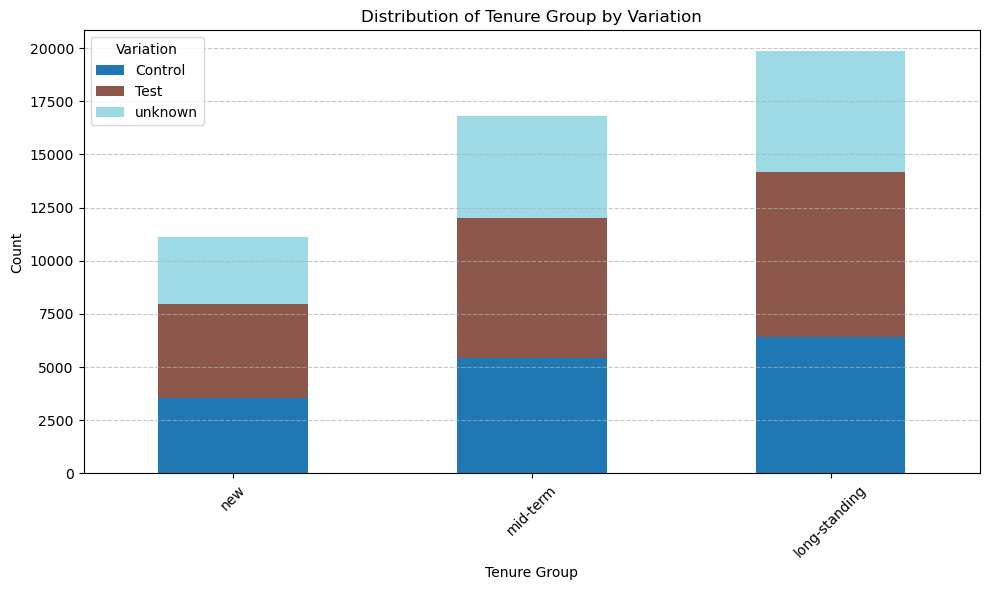

In [ ]:
# Value counts for combinations of 'tenure_group' and 'variation'
grouped_counts = cleaned_confirmed.groupby(['tenure_group', 'Variation']).size().unstack(fill_value=0)

# Display the value counts
print("\nValue counts for tenure_group and variation:")
print(grouped_counts)

# Plotting
plt.figure(figsize=(10, 6))
grouped_counts.plot(kind='bar', stacked=True, colormap='tab20', ax=plt.gca())
plt.title('Distribution of Tenure Group by Variation')
plt.xlabel('Tenure Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Variation')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Duration Assessment

In [ ]:
# Counts how many visitors there was per day
visitors_per_day = all_data.groupby('date')['visitor_id'].nunique()

# Observe descreptive statistics
print(visitors_per_day.describe())

count      98.000000
mean     1561.255102
std      1539.292858
min       101.000000
25%       588.500000
50%      1162.500000
75%      1941.250000
max      8645.000000
Name: visitor_id, dtype: float64


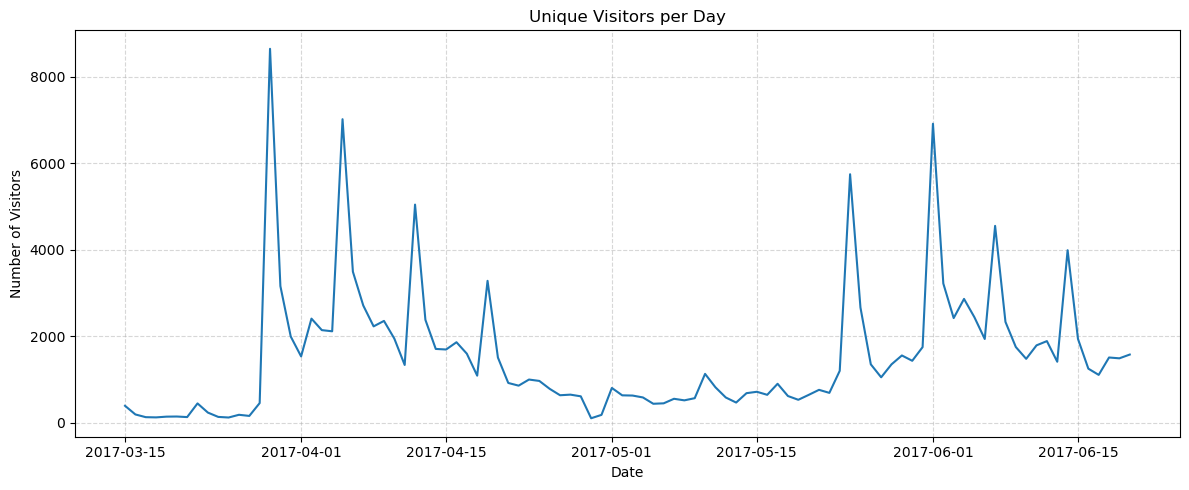

In [ ]:
plt.figure(figsize=(12, 5))
visitors_per_day.plot()
plt.title('Unique Visitors per Day')
plt.xlabel('Date')
plt.ylabel('Number of Visitors')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()